# 7. Majorana propagation

This notebook demonstrates Majorana propagation as a method to simulate quantum time evolution.

References:
- Aaron Miller, Joachim Favre, Zoë Holmes, Özlem Salehi, Rahul Chakraborty, Anton Nykänen, Zoltán Zimborás, Adam Glos, Guillermo García-Pérez  
  Simulation of fermionic circuits using Majorana propagation  
  [arXiv:2503.18939](https://arxiv.org/abs/2503.18939)
- Matteo D'Anna, Yuxuan Zhang, Roeland Wiersema, Manuel S. Rudolph, Juan Carrasquilla  
  Circuit compression for 2D quantum dynamics  
  [arXiv:2507.01883](https://arxiv.org/abs/2507.01883)

In [1]:
import fermi_relations as fr
import numpy as np
from scipy.linalg import expm
from scipy import sparse
import scipy.sparse.linalg as spla

We work with strings of Majorana operators (analogous to Pauli strings), defined in Eq. (2) of _Simulation of fermionic circuits using Majorana propagation_:
\begin{equation*}
s_b = i^{r_b} m_0^{b_0} m_1^{b_1} \cdots m_{2L-1}^{b_{2L-1}}.
\end{equation*}
Here, $m_j$ is the $j$-th Majorana operator, $b \in \{ 0, 1 \}^{2L}$ is a bit string (which we will encode as an integer in the following), and $i^{r_b}$ is a complex phase factor to ensure that the Majorana string is Hermitian.

We can enumerate a basis of Majorana strings as follows (stored as flattened column vectors):

In [2]:
# number of modes (or orbitals) L
nmodes = 6

mbasis = fr.construct_majorana_string_basis(nmodes)
print("mbasis.shape:", mbasis.shape)
print("mbasis.dtype:", mbasis.dtype)

mbasis.shape: (4096, 4096)
mbasis.dtype: complex128


In [3]:
# first string is the identity matrix
spla.norm(mbasis[:, 0].reshape(2 * (2**nmodes,)) - sparse.identity(2**nmodes))

np.float64(0.0)

In [4]:
# unitary up to a scaling factor
spla.norm(mbasis.conj().T @ mbasis - 2**nmodes * sparse.identity(4**nmodes))

np.float64(0.0)

In [5]:
# check Hermitian property of each Majorana string
for v in mbasis.T:
    mstring = v.reshape(2 * (2**nmodes,))
    assert spla.norm(mstring.conj().T - mstring) == 0

Conjugating a Majorana string $s_b$ with the matrix exponential of another anti-commuting Majorana string $s_a$ results in a sum of two Majorana strings, see Eq. (5) in _Simulation of fermionic circuits using Majorana propagation_, with $\theta \in \mathbb{R}$:
\begin{equation*}
e^{i \theta s_a / 2} s_b e^{-i \theta s_a / 2} = \cos(\theta) s_b + i \sin(\theta) s_a s_b
\end{equation*}

In [6]:
# arbitrary angle
theta = 2 * np.pi * 0.7

# Majorana string 'a'
ima = 13
msa = mbasis[:, ima].reshape(2 * (2**nmodes,))

# Majorana string 'b'
imb = 10
msb = mbasis[:, imb].reshape(2 * (2**nmodes,))

# should not commute (otherwise conjugation by matrix exponential has no effect)
print(spla.norm(fr.comm(msa, msb)) == 0)
print(fr.majorana_strings_commute(ima, imb))

# matrix exponential of Majorana string 'a'
expitha = expm(-0.5j * theta * msa.todense())

# difference should be zero,
# see Eq. (5) in "Simulation of fermionic circuits using Majorana propagation"
np.linalg.norm(expitha.conj().T @ msb @ expitha
               - (np.cos(theta) * msb + 1j * np.sin(theta) * (msa @ msb)))

False
False


np.float64(1.2560739669470201e-15)

The following function applies this equation to a linear combination of Majorana strings, stored as an index-value dictionary.

In [7]:
def majorana_time_step(ima: int, theta: float, mvec: dict) -> dict:
    r"""
    Time-propagate a linear combination of Majorana strings,
    stored as an index-value dictionary in 'mvec',
    implementing a logical conjugation by :math:`e^{-i \theta ima / 2}`.
    """
    entries = []
    for imb, coeff in mvec.items():
        if fr.majorana_strings_commute(ima, imb):
            entries.append((imb, coeff))
        else:
            entries.append((imb, coeff * np.cos(theta)))
            imp, phase = fr.majorana_string_product(ima, imb)
            entries.append((imp, 1j * phase * coeff * np.sin(theta)))
    # accumulate coefficients corresponding to same indices
    res = {}
    for imp, coeff in entries:
        if imp in res:
            res[imp] += coeff
        else:
            res[imp] = coeff
    return res

In [8]:
# example linear combination of Majorana strings
mvec_init = { 0: 0.07, 5: 0.1 - 0.2j, 6: 0.3, 10: 0.4, 27: 0.5j }

mvec_step = majorana_time_step(ima, theta, mvec_init)
print(mvec_step)

{0: 0.07, 5: (0.1-0.2j), 6: np.float64(-0.09270509831248426), 11: (-0.285316954888546+0j), 10: np.float64(-0.12360679774997903), 7: (0.3804226065180614-0j), 27: 0.5j}


In [9]:
# reference calculation

# convert input and propagated state to operators
mvec_op = sum(coeff * mbasis[:, im].reshape(2 * (2**nmodes,)) for im, coeff in mvec_init.items())
mvec_step_op = sum(coeff * mbasis[:, im].reshape(2 * (2**nmodes,)) for im, coeff in mvec_step.items())

# reference propagated operator
mvec_op_step_ref = expitha.conj().T @ mvec_op @ expitha

# compare (difference should be zero)
np.linalg.norm(mvec_step_op.toarray() - mvec_op_step_ref)

np.float64(8.044330061068549e-16)

We can now implement Majorana propagation by performing several time steps and truncating (omitting) strings with small coefficients or large length (number of individual Majorana operators).

In [10]:
def truncate_majorana_strings(mvec: dict, tol: float, maxlen: int) -> dict:
    """
    Truncate a linear combination of encoded Majorana strings
    by retaining only strings with coefficients larger than 'tol' (in absolute value)
    and length at most 'maxlen'.
    """
    return { im: coeff for im, coeff in mvec.items() if abs(coeff) > tol and im.bit_count() <= maxlen }

In [11]:
def majorana_propagation(ima_list, theta_list, mvec: dict, tol: float, maxlen: int):
    """
    Perform Majorana propagation with truncation.
    """
    mvec_prop = [mvec]
    for ima, theta in zip(ima_list, theta_list):
        mvec = majorana_time_step(ima, theta, mvec)
        mvec = truncate_majorana_strings(mvec, tol, maxlen)
        mvec_prop.append(mvec)
    return mvec_prop

In [12]:
nsteps = 100

# random number generator
rng = np.random.default_rng(48)

# define (small) random angles and Majorana strings for matrix exponentials
theta_list = 2 * np.pi * 0.01 * rng.uniform(size=nsteps)
ima_list = [int(rng.integers(2**(2*nmodes))) for _ in range(nsteps)]

# truncate solely based on coefficients
tol_list = [0, 1e-6, 1e-4, 1e-2]
mvec_prop_list1 = {}
for tol in tol_list:
    mvec_prop_list1[tol] = majorana_propagation(ima_list, theta_list, mvec_init, tol, 2*nmodes)

# truncate solely based on length
maxlen_list = [2*nmodes, 10, 8, 6]
mvec_prop_list2 = {}
for maxlen in maxlen_list:
    mvec_prop_list2[maxlen] = majorana_propagation(ima_list, theta_list, mvec_init, 0., maxlen)


In [13]:
# reference calculation

mbasis_dense = mbasis.todense()

# convert input state to an operator
mvec_op = sum(coeff * mbasis_dense[:, im].reshape(2 * (2**nmodes,)) for im, coeff in mvec_init.items())

mvec_op_prop_ref = [mvec_op]
for ima, theta in zip(ima_list, theta_list):
    # matrix exponential of Majorana string 'ima'
    expitha = expm(-0.5j * theta * mbasis_dense[:, ima].reshape(2 * (2**nmodes,)))
    mvec_op = expitha.conj().T @ mvec_op @ expitha
    mvec_op_prop_ref.append(mvec_op)

In [14]:
# record relative errors

err_list1 = {}
for tol in tol_list:
    err_list1[tol] = []
    for i in range(nsteps + 1):
        mop = sum(coeff * mbasis_dense[:, im].reshape(2 * (2**nmodes,))
                  for im, coeff in mvec_prop_list1[tol][i].items())
        err_list1[tol].append(np.linalg.norm(mop - mvec_op_prop_ref[i])
                              / np.linalg.norm(mvec_op_prop_ref[i]))

err_list2 = {}
for maxlen in maxlen_list:
    err_list2[maxlen] = []
    for i in range(nsteps + 1):
        mop = sum(coeff * mbasis_dense[:, im].reshape(2 * (2**nmodes,))
                  for im, coeff in mvec_prop_list2[maxlen][i].items())
        err_list2[maxlen].append(np.linalg.norm(mop - mvec_op_prop_ref[i])
                                 / np.linalg.norm(mvec_op_prop_ref[i]))

In [15]:
import matplotlib.pyplot as plt

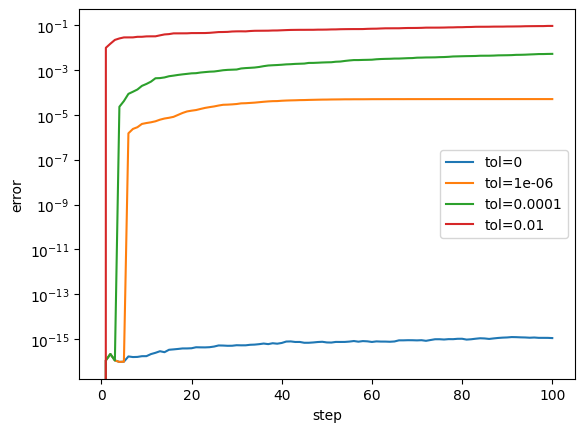

In [16]:
# visualize errors for coefficient truncation

for tol in tol_list:
    plt.semilogy(err_list1[tol], label=f"tol={tol}")
plt.xlabel("step")
plt.ylabel("error")
plt.legend()
plt.show()

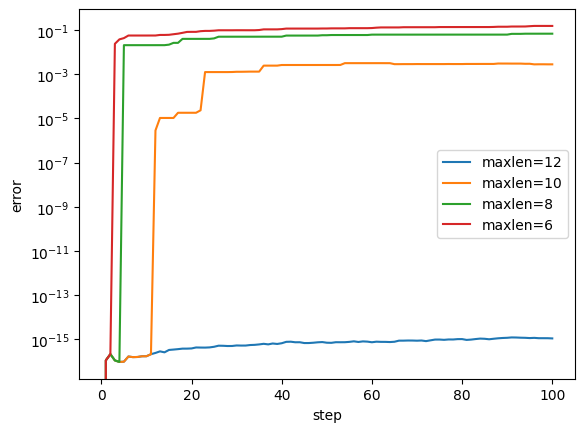

In [17]:
# visualize errors for length truncation

for maxlen in maxlen_list:
    plt.semilogy(err_list2[maxlen], label=f"maxlen={maxlen}")
plt.xlabel("step")
plt.ylabel("error")
plt.legend()
plt.show()